# DermMel Dataset Exploration

このノートブックでは、DermMelデータセット（皮膚病変画像）の内容を確認します。

In [1]:
import os
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# データセットのパス
DATA_DIR = '/mnt/data1/Public/MedImages/DermMel'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_sep')

In [2]:
# データセット構造の確認
if os.path.exists(TRAIN_IMG_DIR):
    print(f"データディレクトリ: {TRAIN_IMG_DIR}")
    subdirs = [d for d in os.listdir(TRAIN_IMG_DIR) if os.path.isdir(os.path.join(TRAIN_IMG_DIR, d))]
    print(f"\nクラスフォルダ: {subdirs}")
    
    # 各クラスの画像数を確認
    for subdir in subdirs:
        class_path = os.path.join(TRAIN_IMG_DIR, subdir)
        images = list(Path(class_path).glob('**/*.jpg')) + list(Path(class_path).glob('**/*.jpeg')) + \
                 list(Path(class_path).glob('**/*.png')) + list(Path(class_path).glob('**/*.tif')) + \
                 list(Path(class_path).glob('**/*.tiff')) + list(Path(class_path).glob('**/*.bmp'))
        print(f"  {subdir}: {len(images)} 画像")
else:
    print(f"ディレクトリが見つかりません: {TRAIN_IMG_DIR}")

データディレクトリ: /mnt/data1/Public/MedImages/DermMel/train_sep

クラスフォルダ: ['NotMelanoma', 'Melanoma']
  NotMelanoma: 5341 画像
  Melanoma: 5341 画像


In [3]:
# 画像パスを再帰的に収集
image_paths = []
extensions = ("jpg", "jpeg", "png", "tif", "tiff", "bmp", "webp")
root_path = Path(TRAIN_IMG_DIR)

for ext in extensions:
    for p in root_path.glob(f"**/*.{ext}"):
        if p.is_file():
            image_paths.append(str(p))

print(f"合計画像数: {len(image_paths)}")

# ランダムに16枚選択
if len(image_paths) >= 16:
    sample_paths = random.sample(image_paths, 16)
else:
    sample_paths = image_paths[:16]
    print(f"警告: 画像が16枚未満です ({len(image_paths)}枚)")

合計画像数: 10682


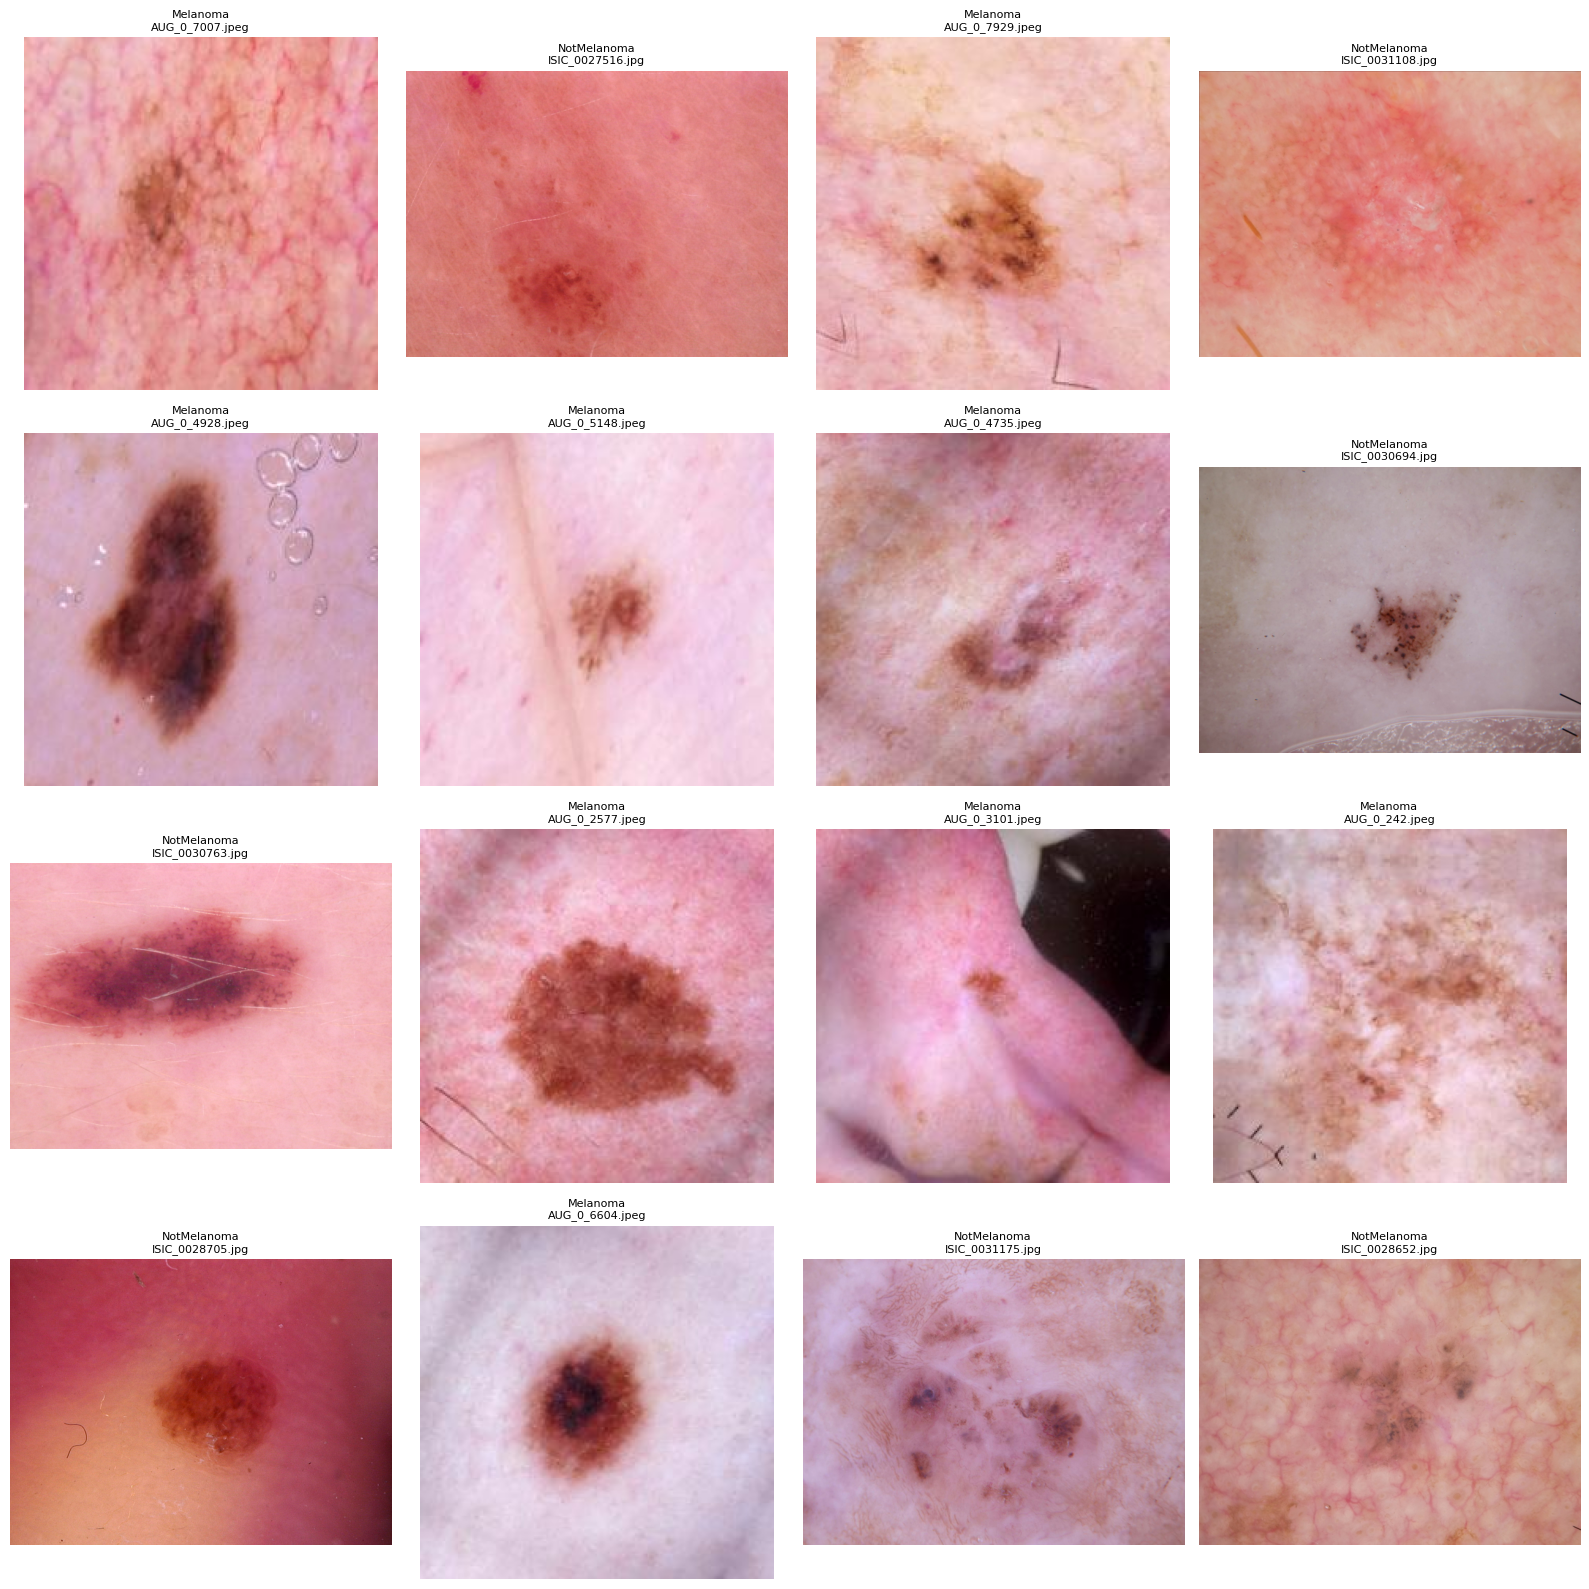


表示した画像サンプル:
1. Melanoma/AUG_0_7007.jpeg
2. NotMelanoma/ISIC_0027516.jpg
3. Melanoma/AUG_0_7929.jpeg
4. NotMelanoma/ISIC_0031108.jpg
5. Melanoma/AUG_0_4928.jpeg
6. Melanoma/AUG_0_5148.jpeg
7. Melanoma/AUG_0_4735.jpeg
8. NotMelanoma/ISIC_0030694.jpg
9. NotMelanoma/ISIC_0030763.jpg
10. Melanoma/AUG_0_2577.jpeg
11. Melanoma/AUG_0_3101.jpeg
12. Melanoma/AUG_0_242.jpeg
13. NotMelanoma/ISIC_0028705.jpg
14. Melanoma/AUG_0_6604.jpeg
15. NotMelanoma/ISIC_0031175.jpg
16. NotMelanoma/ISIC_0028652.jpg


In [4]:
# 16枚の画像を4x4グリッドで表示
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx, img_path in enumerate(sample_paths):
    try:
        img = Image.open(img_path).convert('RGB')
        axes[idx].imshow(img)
        
        # ファイル名とクラス名を表示
        filename = Path(img_path).name
        parent_dir = Path(img_path).parent.name
        axes[idx].set_title(f"{parent_dir}\n{filename[:20]}", fontsize=8)
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\n表示した画像サンプル:")
for i, path in enumerate(sample_paths, 1):
    print(f"{i}. {Path(path).parent.name}/{Path(path).name}")

In [5]:
# 画像サイズの分布を確認
print("サンプル画像のサイズ:")
sizes = []
for img_path in sample_paths[:5]:  # 最初の5枚だけチェック
    try:
        img = Image.open(img_path)
        print(f"  {Path(img_path).name}: {img.size} (width x height)")
        sizes.append(img.size)
    except Exception as e:
        print(f"  Error loading {img_path}: {e}")

サンプル画像のサイズ:
  AUG_0_7007.jpeg: (224, 224) (width x height)
  ISIC_0027516.jpg: (600, 450) (width x height)
  AUG_0_7929.jpeg: (224, 224) (width x height)
  ISIC_0031108.jpg: (600, 450) (width x height)
  AUG_0_4928.jpeg: (224, 224) (width x height)
